# Project: Unemployment Analysis with Python
**Author:** Muhammad Anas Zakir | **Contact:** anaszakir.pro@gmail.com

**Context:** Completed as part of the CodeAlpha Data Science Internship

**Objective:** Analyze the unemployment rate in India, investigate the economic impact of the COVID-19 pandemic, and identify key patterns across different regions and demographics.

## 1. Data Import and Setup
To begin, we import the necessary data manipulation libraries and load our raw dataset into a pandas DataFrame.

In [19]:
import pandas as pd

In [20]:
df1 = pd.read_csv("Unemployment in India.csv")

## 2. Initial Data Inspection
Before cleaning the data, we need to understand its structure. By checking the DataFrame's info and looking for missing values, we can identify exactly what needs to be fixed before performing any calculations.

*   **Data Types:** We need to verify if dates are formatted as text or datetime objects.
*   **Missing Values:** We will check if there are any blank rows or incomplete records that could break our analysis.

In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [22]:
df1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

## 3. Structural Data Cleaning: Handling Missing Values
Our initial inspection revealed exactly 28 missing values (`NaN`) across every single column. This indicates that there are 28 completely blank rows at the end of our dataset, likely caused by an export error. 

Since these rows contain no useful information, we will drop them entirely to ensure our statistical formulas and visualizations function correctly.

In [23]:
df1 = df1.dropna()

## 4. Structural Data Cleaning: Standardizing Column Names
When importing raw CSV files, column headers often contain invisible leading or trailing spaces (e.g., `' Date '` instead of `'Date'`). If left unaddressed, calling a column will result in a `KeyError`. 

By printing the raw column names as a list, we can visually identify these hidden spaces and use the `.str.strip()` method to remove them, ensuring our column references remain clean and predictable.

In [24]:
print(df1.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [25]:
df1.columns = df1.columns.str.strip()

## 5. Structural Data Cleaning: Datetime Conversion
By default, pandas loads dates as generic string objects (`dtype: object`). To perform time-series analysis—which is critical for tracking the progression of the COVID-19 pandemic—we must convert the 'Date' column into a proper `datetime` object. 

In [26]:
df1['Date'] = pd.to_datetime(df1['Date'])

C:\Users\anasz\AppData\Local\Temp\ipykernel_30244\1148610173.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df1['Date'] = pd.to_datetime(df1['Date'])


## 6. Exploratory Data Analysis (EDA): Summary Statistics
With the dataset structurally clean, we transition to logical cleaning and exploration. Using the `.describe()` function, we can instantly generate summary statistics to check for data entry errors, calculate baselines, and spot extreme anomalies.

**Key Observations:**
* **The COVID-19 Shock:** The maximum estimated unemployment rate is a staggering 76.74%, directly reflecting the severe economic impact of pandemic lockdowns.
* **Suspicious Minimums:** The minimum unemployment rate is exactly 0.00%. In labor economics, a true 0% unemployment rate across an entire region is highly improbable and likely represents a data collection failure or placeholder, which requires further investigation.

In [27]:
df1.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


## 7. Exploratory Data Analysis (EDA): Outlier Detection
While line charts show us trends over time, boxplots are the standard tool for showing data distribution and isolating mathematical outliers. 

**Key Insight:** 
The light blue box represents where the vast majority of our data lives (the normal baseline). The individual circles stretching far to the right are statistical outliers. However, in the context of our analysis, these are **true anomalies**—they represent the actual, massive job losses caused by COVID-19 lockdowns. We will keep these high values as they are the core focus of the project.

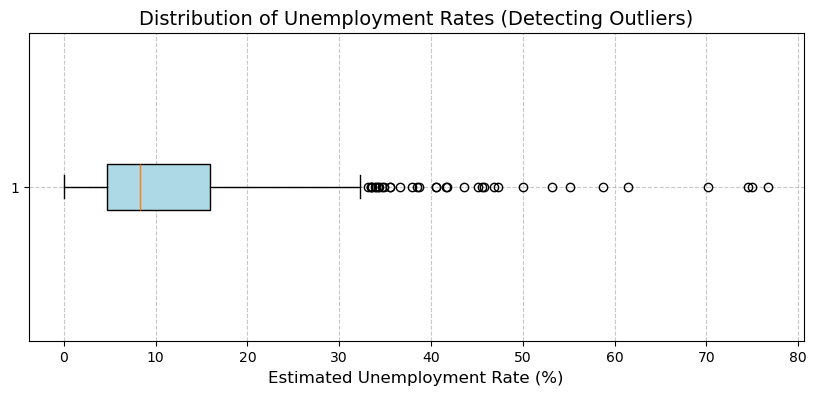

In [28]:
plt.figure(figsize=(10, 4))
plt.boxplot(df1['Estimated Unemployment Rate (%)'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Distribution of Unemployment Rates (Detecting Outliers)', fontsize=14)
plt.xlabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## 9. Logical Data Cleaning: Handling Bad Outliers
While the high outliers represent real economic events, our initial `.describe()` table flagged a suspicious minimum unemployment rate of exactly `0.0%`. 

By isolating these specific rows, we can see that a 0% rate is repeatedly reported for regions like Puducherry. In macroeconomics, a true 0% unemployment rate across an entire state is virtually impossible. This strongly indicates a data collection failure (reporting a `0` instead of leaving the field blank for missing data). 

To ensure our average calculations are not artificially dragged down by these reporting errors, we will filter them out of the dataset before moving on to our final insights.

In [29]:
zero_outliers = df1[df1['Estimated Unemployment Rate (%)'] == 0.0]
display(zero_outliers)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
25,Assam,2020-06-30,Monthly,0.0,7544937.0,34.38,Rural
51,Chhattisgarh,2020-04-30,Monthly,0.0,6534321.0,39.43,Rural
77,Goa,2020-02-29,Monthly,0.0,171672.0,36.11,Rural
231,Puducherry,2019-05-31,Monthly,0.0,172474.0,43.08,Rural
232,Puducherry,2019-06-30,Monthly,0.0,184527.0,45.95,Rural
233,Puducherry,2019-07-31,Monthly,0.0,139227.0,34.56,Rural
235,Puducherry,2019-09-30,Monthly,0.0,175718.0,43.34,Rural
237,Puducherry,2019-11-30,Monthly,0.0,142787.0,35.00,Rural
274,Sikkim,2020-04-30,Monthly,0.0,133399.0,37.72,Rural
617,Puducherry,2019-06-30,Monthly,0.0,304369.0,37.73,Urban


In [30]:
df1 = df1[df1['Estimated Unemployment Rate (%)'] > 0.0]

print("Remaining rows:", len(df1))

Remaining rows: 729


## 8. Data Visualization: The Macro Impact of COVID-19
To understand the overarching trend, we group the dataset by month and calculate the national average unemployment rate. Plotting this on a time-series line chart allows us to clearly visualize the "before, during, and after" phases of the initial pandemic shock.

**Key Insight:**
The chart clearly maps the economic timeline of the pandemic. The baseline unemployment rate hovered naturally between 8% and 11% throughout 2019 and early 2020. However, there is a drastic, near-vertical spike starting in late March 2020, peaking at nearly 25% in May. This visually confirms the immediate and severe macro-economic paralysis caused by the COVID-19 lockdown measures.

In [31]:
import matplotlib.pyplot as plt

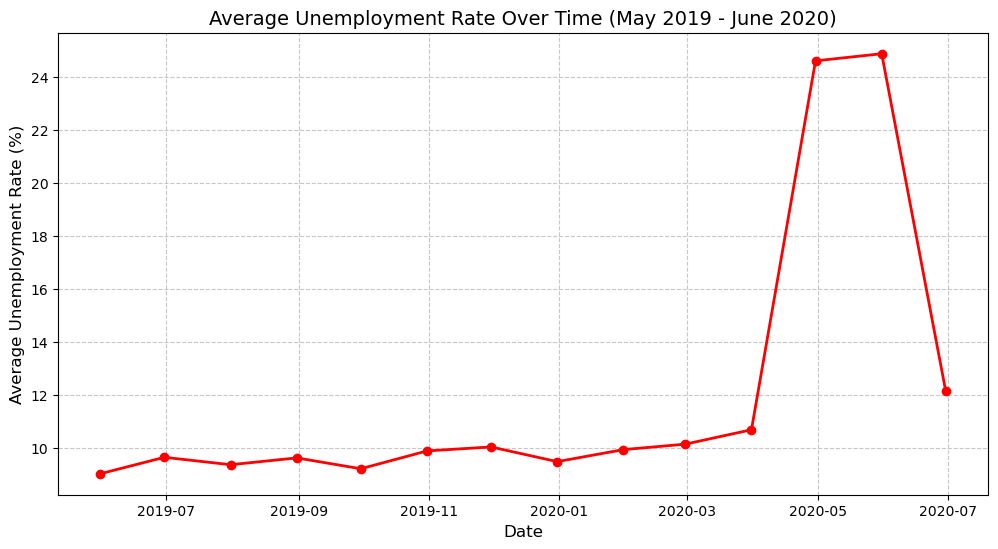

In [32]:
monthly_trend = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend.values, color='red', marker='o', linewidth=2)

plt.title('Average Unemployment Rate Over Time (May 2019 - June 2020)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 10. Deep Dive Analysis: Urban vs. Rural Impact
To present actionable policy insights, we must look beyond the national average. By segmenting the data using the `Area` column (Urban vs. Rural), we can determine if the COVID-19 lockdowns disproportionately affected specific demographic sectors. We use the `seaborn` library here because its `hue` parameter makes plotting split categories incredibly efficient.

**Key Insight for Policymakers:**
The visualization reveals a clear divergence during the lockdown months. While both sectors suffered severe job losses, **Urban unemployment spiked significantly higher** (reaching nearly 29%) compared to Rural unemployment (peaking around 24%). 

This strongly suggests that urban-centric sectors like retail, hospitality, and corporate offices experienced immediate and catastrophic shutdowns. In contrast, rural economies, which are often anchored by agriculture and localized supply chains, were slightly more insulated as "essential" work. Future economic relief policies should therefore prioritize targeted aid for urban service-sector workers during similar public health lockdowns.

In [33]:
import seaborn as sns

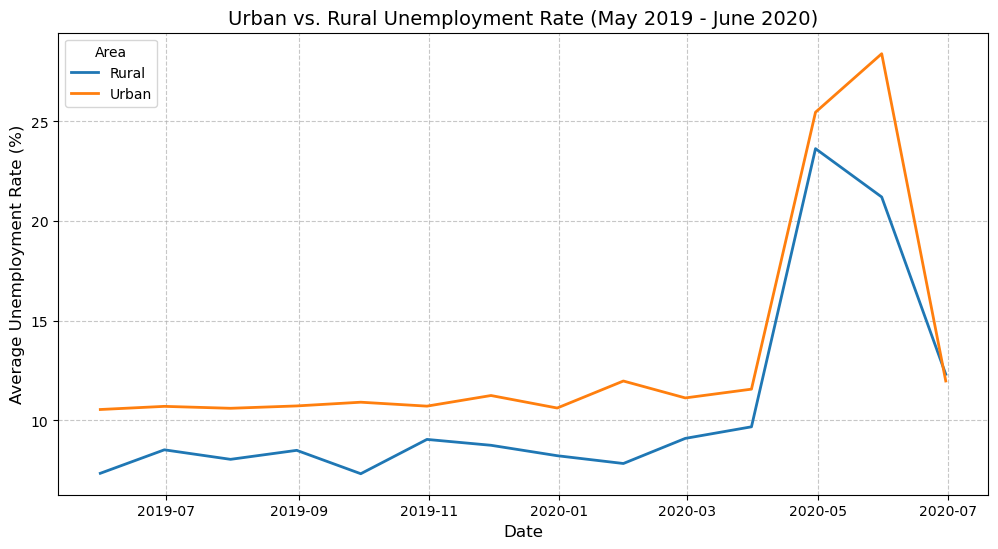

In [34]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df1, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', errorbar=None, linewidth=2)

plt.title('Urban vs. Rural Unemployment Rate (May 2019 - June 2020)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 11. Deep Dive Analysis: State-by-State Lockdown Impact
To fully understand the geographic distribution of the economic shock, we need to isolate our timeline exclusively to the peak lockdown period (April to June 2020). By grouping the data by state and calculating the average unemployment rate during this specific window, we can identify which regions were most vulnerable and which were most resilient. 

**Key Insight for Policymakers:**
The bar chart reveals a massive geographic disparity in how the pandemic affected local economies. Regions like **Puducherry, Jharkhand, and Haryana** experienced devastating job losses, with Puducherry's average unemployment nearing an apocalyptic 60%. Conversely, states at the bottom of the chart like Chandigarh and Assam remained highly insulated with rates under 10%. 

This proves that a blanket, one-size-fits-all national economic relief policy would be inefficient. Relief funds and intervention strategies must be aggressively targeted at the state level based on localized vulnerability.

C:\Users\anasz\AppData\Local\Temp\ipykernel_30244\1721282499.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_impact.values, y=state_impact.index, palette='Reds_r')


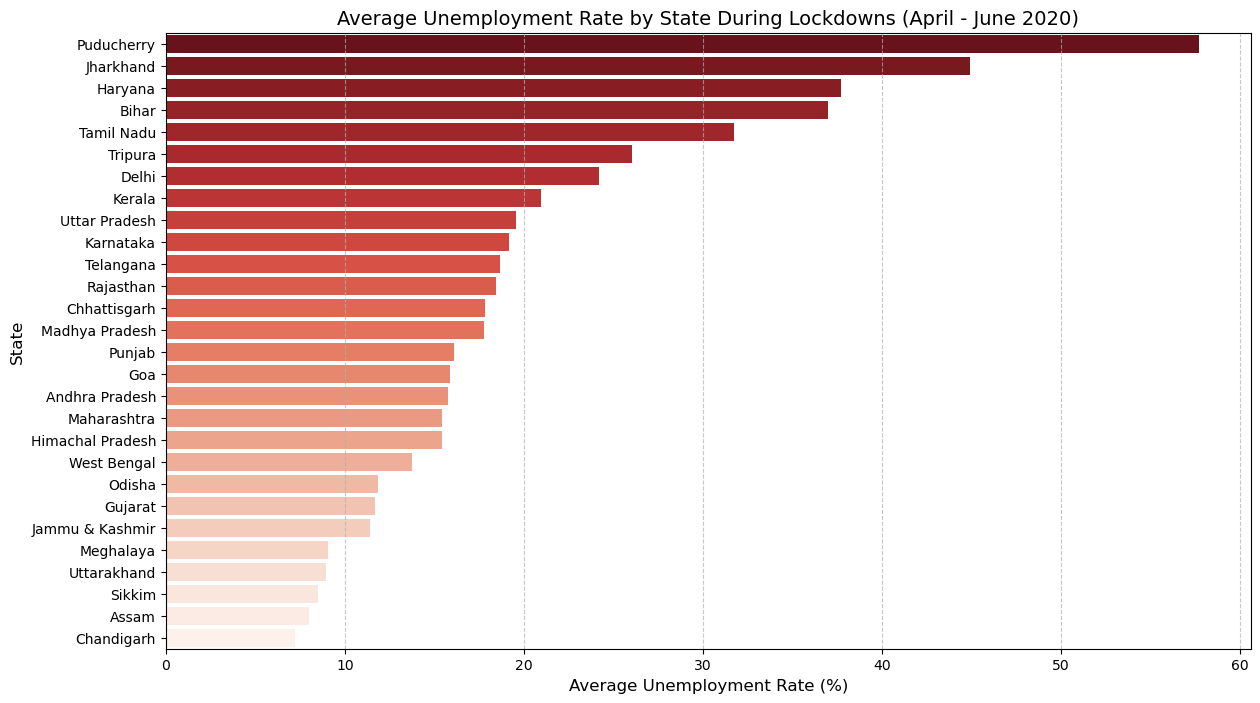

In [35]:
lockdown_data = df1[(df1['Date'] >= '2020-04-01') & (df1['Date'] <= '2020-06-30')]

state_impact = lockdown_data.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))

sns.barplot(x=state_impact.values, y=state_impact.index, palette='Reds_r')

plt.title('Average Unemployment Rate by State During Lockdowns (April - June 2020)', fontsize=14)
plt.xlabel('Average Unemployment Rate (%)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.show()